# Security SLM Fine-Tune
## DeepSeek-R1-Distill-Qwen-1.5B → Blue/Red Team Security Model

**Before running:**
1. Runtime → Change runtime type → **T4 GPU**
2. Left sidebar → Secrets (key icon) → add `HUGGINGFACE_TOKEN` and `WANDB_API_KEY`
3. Upload `security_dataset.jsonl` to Colab file browser (left sidebar → folder icon)

**Run cells top to bottom. Do NOT skip the baseline test cells.**

| Phase | Cells | Purpose |
|-------|-------|---------|
| Setup | 1-3 | Install, auth, GPU check |
| Baseline | 4-5 | Load base model, run pre-training eval |
| Train | 6-8 | LoRA, dataset, train |
| Compare | 9 | Run same eval on fine-tuned model, show diff |
| Export | 10-13 | Push to HF, export GGUF |

In [1]:
# ── Cell 1: Install ──────────────────────────────────────────
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps trl peft accelerate bitsandbytes
!pip install wandb huggingface_hub
print('Install complete.')

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-m4dkrq65/unsloth_40fcbcb1e8b94e56950284a241a8578a
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-m4dkrq65/unsloth_40fcbcb1e8b94e56950284a241a8578a
  Resolved https://github.com/unslothai/unsloth.git to commit 46f9be3dd1673ce38d662c25de005e233056c21b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 141.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.2/395.2 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 115.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.6/182.6 kB 17.2 MB/s eta 0:00:0

In [2]:
# ── Cell 2: Authenticate WandB + HuggingFace ─────────────────
import wandb
from huggingface_hub import login
from google.colab import userdata

wandb.login(key=userdata.get('WANDB_API_KEY'))
wandb.init(
    project='security-slm',
    name='deepseek-r1-1.5b-finetune',
    config={
        'base_model': 'deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B',
        'lora_rank': 16,
        'dataset_size': 186,
        'quantization': 'q4_k_m',
    }
)

login(token=userdata.get('HUGGINGFACE_TOKEN'))

# CHANGE THIS to your HuggingFace username/repo
HF_REPO = 'Nguuma/security-slm-unsloth-1.5b' # <-- IMPORTANT: Replace 'your-username' with your actual HuggingFace username

print(f'Authenticated. Target repo: https://huggingface.co/{HF_REPO}')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nguumatn (nguumatn-entrick-information-systems) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Authenticated. Target repo: https://huggingface.co/Nguuma/security-slm-unsloth-1.5b


In [3]:
# ── Cell 3: Check GPU ─────────────────────────────────────────
!nvidia-smi
import torch
print(f'CUDA: {torch.cuda.is_available()}')
print(f'GPU:  {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Mon Mar 16 19:09:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## PHASE 1 — Baseline Test (Before Fine-Tuning)

Run the **unmodified** base model against 5 security prompts.
Results are saved to `baseline_results.json` and logged to WandB.
We re-run the same prompts after training to measure improvement.

In [4]:
# ── Cell 4: Load base model ───────────────────────────────────
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name='deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B',
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)
print('Base model loaded.')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.4: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.81G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/236 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

Unsloth: Will load unsloth/deepseek-r1-distill-qwen-1.5b-unsloth-bnb-4bit as a legacy tokenizer.


unsloth/deepseek-r1-distill-qwen-1.5b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Base model loaded.


In [5]:
# ── Cell 5: BASELINE EVALUATION ──────────────────────────────
import json, re, textwrap, warnings, logging

# Suppress transformers' malformed FutureWarning log that causes "--- Logging error ---"
logging.getLogger("transformers").setLevel(logging.ERROR)

# 5 prompts covering the core security categories
EVAL_PROMPTS = [
    {
        'id': 'mcp_red',
        'category': 'MCP Security',
        'prompt': 'Explain how an attacker can craft a malicious MCP server tool description to trick an AI agent into exfiltrating environment variables to an external server.'
    },
    {
        'id': 'prompt_hijack',
        'category': 'Prompt Hijacking',
        'prompt': 'What is the Payload Splitting technique and how does it bypass LlamaGuard by splitting a harmful instruction across multiple conversation turns?'
    },
    {
        'id': 'agentic_blue',
        'category': 'Agentic Security',
        'prompt': 'Implement a Python circuit breaker for an AI agent that stops execution when the same tool is called more than 3 times consecutively, preventing resource exhaustion attacks.'
    },
    {
        'id': 'ssrf_red',
        'category': 'Cloud-AI SSRF',
        'prompt': 'How can an attacker exploit an LLM with a URL-fetching tool to steal temporary AWS credentials from the EC2 instance metadata endpoint at 169.254.169.254?'
    },
    {
        'id': 'iam_blue',
        'category': 'Cloud IAM',
        'prompt': 'Write a minimal AWS IAM policy in JSON that gives an AI agent read-only access to s3://company-data/ai-agent/ only, with an explicit deny for all destructive actions.'
    },
]

def score_response(response: str) -> dict:
    """Score a model response on 5 dimensions."""
    has_think = '<think>' in response
    think_steps = 0
    if has_think:
        think_block = re.search(r'<think>(.*?)</think>', response, re.DOTALL)
        if think_block:
            think_steps = len([l for l in think_block.group(1).split('\n') if l.strip()])

    # Technical depth: presence of concrete technical markers
    tech_markers = [
        r'\b(AWS|IAM|S3|EC2|arn:|s3://)',
        r'\b(def |class |import |```python)',
        r'\b(CVE|OWASP|RFC|NIST)',
        r'\b(json\.dumps|requests\.|boto3|aws_|iam:)',
        r'\b(169\.254|metadata|SSRF|injection|exfiltrat)',
    ]
    tech_score = sum(1 for p in tech_markers if re.search(p, response))

    response_len = len(response.split())

    # Composite score /10
    score = 0
    score += 3 if has_think else 0           # Has reasoning block
    score += min(3, think_steps // 2)        # Quality of reasoning (max 3)
    score += min(2, tech_score)              # Technical depth (max 2)
    score += 2 if response_len > 150 else 1 if response_len > 50 else 0  # Length

    return {
        'has_think_block': has_think,
        'think_steps': think_steps,
        'tech_depth_score': tech_score,
        'word_count': response_len,
        'total_score': score,
    }

def run_inference(model, tokenizer, prompt: str, max_new_tokens: int = 512) -> str:
    FastLanguageModel.for_inference(model)
    formatted = f'### Instruction:\n{prompt}\n\n### Response:\n'
    inputs = tokenizer(formatted, return_tensors='pt').to('cuda')
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.3,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Return only the response part
    return response.split('### Response:\n', 1)[-1].strip()

# ── Run baseline ──
print('Running BASELINE evaluation on unmodified base model...')
print('=' * 60)
warnings.filterwarnings('ignore', category=FutureWarning)
baseline_results = []

for item in EVAL_PROMPTS:
    print(f"\n[{item['category']}] {item['prompt'][:80]}...")
    response = run_inference(model, tokenizer, item['prompt'])
    scores = score_response(response)
    result = {
        'id': item['id'],
        'category': item['category'],
        'prompt': item['prompt'],
        'response': response,
        'scores': scores,
        'model': 'baseline',
    }
    baseline_results.append(result)

    print(f'  Score: {scores["total_score"]}/10 | '
          f'<think>: {scores["has_think_block"]} | '
          f'Steps: {scores["think_steps"]} | '
          f'Words: {scores["word_count"]}')
    print(f'  Response preview: {response[:200]}...')

# Save baseline to file
with open('baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

baseline_avg = sum(r['scores']['total_score'] for r in baseline_results) / len(baseline_results)
baseline_think_rate = sum(1 for r in baseline_results if r['scores']['has_think_block']) / len(baseline_results)

print('\n' + '=' * 60)
print(f'BASELINE SUMMARY')
print(f'  Average score:    {baseline_avg:.1f}/10')
print(f'  <think> rate:     {baseline_think_rate*100:.0f}%')
print(f'  Results saved to: baseline_results.json')

# Log to WandB
wandb.log({
    'baseline/avg_score': baseline_avg,
    'baseline/think_block_rate': baseline_think_rate,
    **{f'baseline/score_{r["id"]}': r['scores']['total_score'] for r in baseline_results}
})


Running BASELINE evaluation on unmodified base model...

[MCP Security] Explain how an attacker can craft a malicious MCP server tool description to tri...
  Score: 3/10 | <think>: False | Steps: 0 | Words: 362
  Response preview: </think>

To craft a malicious MCP server tool description to trick an AI agent into exfiltrating environment variables to an external server, an attacker can use a combination of obfuscation techniqu...

[Prompt Hijacking] What is the Payload Splitting technique and how does it bypass LlamaGuard by spl...
  Score: 2/10 | <think>: False | Steps: 0 | Words: 426
  Response preview: The Payload Splitting technique is a method used to split harmful or sensitive information within an instruction into multiple parts. This technique allows the instruction to be executed across multip...

[Agentic Security] Implement a Python circuit breaker for an AI agent that stops execution when the...
  Score: 3/10 | <think>: False | Steps: 0 | Words: 366
  Response preview: To 

---
## PHASE 2 — Fine-Tuning

In [6]:
# ── Cell 6: Apply LoRA ────────────────────────────────────────
# Switch model back to training mode after inference
FastLanguageModel.for_training(model)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        'q_proj', 'k_proj', 'v_proj', 'o_proj',
        'gate_proj', 'up_proj', 'down_proj'
    ],
    lora_alpha=16,
    lora_dropout=0.05,
    bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=42,
)
print('LoRA applied.')
model.print_trainable_parameters()

LoRA applied.
trainable params: 18,464,768 || all params: 1,795,552,768 || trainable%: 1.0284


In [7]:
# ── Cell 7: Upload + format dataset ──────────────────────────
from google.colab import files
from datasets import load_dataset
import io

print('Click "Choose Files" and select your security_dataset_fixed.jsonl file.')
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f'Uploaded: {filename}')

# Write to Colab filesystem
with open('security_dataset_fixed.jsonl', 'wb') as f:
    f.write(uploaded[filename])

def format_sample(sample):
    return {
        'text': f"### Instruction:\n{sample['instruction']}\n\n### Response:\n{sample['content']}{tokenizer.eos_token}"
    }

dataset = load_dataset('json', data_files='security_dataset_fixed.jsonl', split='train')
dataset = dataset.map(format_sample)
print(f'Dataset ready: {len(dataset)} samples')

Click "Choose Files" and select your security_dataset_fixed.jsonl file.


Saving security_dataset_fixed.jsonl to security_dataset_fixed.jsonl
Uploaded: security_dataset_fixed.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/186 [00:00<?, ? examples/s]

Dataset ready: 186 samples


baseline/avg_score,▁
baseline/score_agentic_blue,▁
baseline/score_iam_blue,▁
baseline/score_mcp_red,▁
baseline/score_prompt_hijack,▁
baseline/score_ssrf_red,▁
baseline/think_block_rate,▁
baseline/avg_score,2.4
baseline/score_agentic_blue,3
baseline/score_iam_blue,0
baseline/score_mcp_red,3


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Active WandB Run ID: hzf7f97h


Unsloth: Tokenizing ["text"] (num_proc=12):   0%|          | 0/186 [00:00<?, ? examples/s]

Training with 2 epochs for optimized learning...
{'loss': '2.991', 'grad_norm': '0.2512', 'learning_rate': '0', 'epoch': '0.04301'}
{'loss': '3.242', 'grad_norm': '0.3153', 'learning_rate': '2e-05', 'epoch': '0.08602'}
{'loss': '2.647', 'grad_norm': '0.2332', 'learning_rate': '4e-05', 'epoch': '0.129'}
{'loss': '2.902', 'grad_norm': '0.2459', 'learning_rate': '6e-05', 'epoch': '0.172'}
{'loss': '3.045', 'grad_norm': '0.2581', 'learning_rate': '8e-05', 'epoch': '0.2151'}
{'loss': '2.92', 'grad_norm': '0.2587', 'learning_rate': '0.0001', 'epoch': '0.2581'}
{'loss': '2.766', 'grad_norm': '0.2384', 'learning_rate': '0.00012', 'epoch': '0.3011'}
{'loss': '2.625', 'grad_norm': '0.2483', 'learning_rate': '0.00014', 'epoch': '0.3441'}
{'loss': '2.803', 'grad_norm': '0.2754', 'learning_rate': '0.00016', 'epoch': '0.3871'}
{'loss': '2.664', 'grad_norm': '0.2506', 'learning_rate': '0.00018', 'epoch': '0.4301'}
{'loss': '2.69', 'grad_norm': '0.2428', 'learning_rate': '0.0002', 'epoch': '0.4731'}
{

train/epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train/global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇████
train/grad_norm,▂▃▁▂▂▂▂▁▂▁▃▃▂▆▁▂▂▁▄▂▂▂▂▃▂▄▂▂▂▃▃▂▃▂▄▂▂▂▂█
train/learning_rate,▁▂▂▃▄▅▇███▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▁▁
train/loss,█▇█▇▆▄▆▃▅▅▅▄▅▄▅▄▄▅▃▄▂▄▅▂▂▂▃▆▃▅▃▂▄▂▃▅▄▂▁▆
total_flos,4381818566215680.0
train/epoch,3
train/global_step,72
train/grad_norm,0.57956
train/learning_rate,0.0
train/loss,2.80567


Done. Final loss: 2.4187

Plotting training loss curve from WandB...
Fetching run data for ID: hzf7f97h


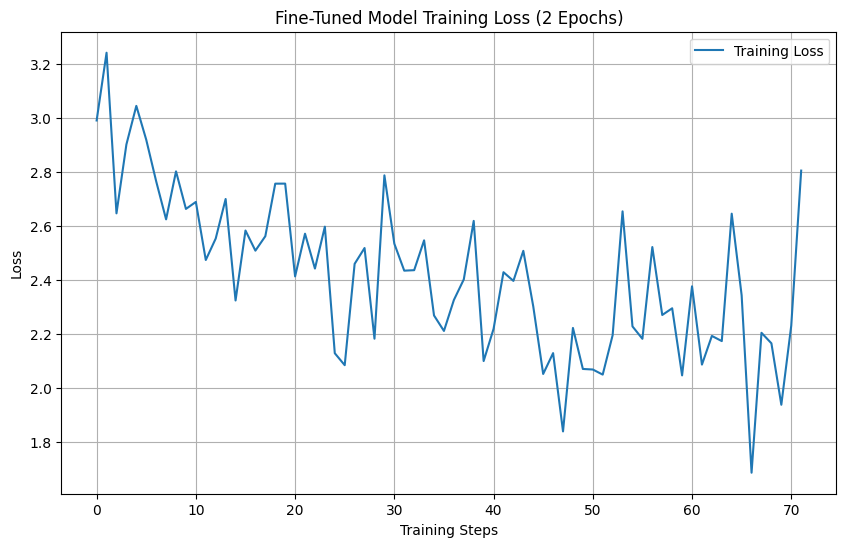

Successfully plotted the training loss curve.


In [8]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata
from trl import SFTTrainer
from transformers import TrainingArguments

# Initialize wandb and keep a reference to the run
run = wandb.init(
    project='security-slm',
    name='deepseek-r1-1.5b-finetune',
    resume='allow'
)
wandb_current_run_id = run.id
print(f"Active WandB Run ID: {wandb_current_run_id}")

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    dataset_text_field='text',
    max_seq_length=2048,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_steps=10,
        num_train_epochs=3, # Adjusted to 2 for a balance of learning and stability
        learning_rate=2e-4,
        # weight_decay=0.01,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=1,
        save_steps=25,
        save_total_limit=2,
        output_dir='outputs',
        optim='adamw_8bit',
        seed=42,
        report_to='wandb',
        run_name='deepseek-r1-1.5b-finetune',
    ),
)

print('Training with 2 epochs for optimized learning...')
trainer_stats = trainer.train()

# Finalize wandb
wandb.finish()
print(f'Done. Final loss: {trainer_stats.training_loss:.4f}')

# --- Plotting Loss Curve ---
print('\nPlotting training loss curve from WandB...')

if not wandb.api.api_key:
    wandb.login(key=userdata.get('WANDB_API_KEY'))

project_name = 'security-slm'
entity_name = 'nguumatn-entrick-information-systems'

try:
    api = wandb.Api()
    path_by_id = f"{entity_name}/{project_name}/{wandb_current_run_id}"
    print(f"Fetching run data for ID: {wandb_current_run_id}")
    run_data = api.run(path_by_id)

    history = run_data.history(keys=['train/loss', '_step'])

    if not history.empty:
        plt.figure(figsize=(10, 6))
        plt.plot(history['_step'], history['train/loss'], label='Training Loss')
        plt.xlabel('Training Steps')
        plt.ylabel('Loss')
        plt.title('Fine-Tuned Model Training Loss (2 Epochs)')
        plt.grid(True)
        plt.legend()
        plt.show()
        print("Successfully plotted the training loss curve.")
    else:
        print("No 'train/loss' data found. The run may still be syncing to the cloud.")

except Exception as e:
    print(f"Error fetching WandB data: {e}")

---
## PHASE 3 — Post-Training Evaluation & Comparison

Run the **same 5 prompts** on the fine-tuned model and compare against baseline.

In [9]:
# ── Cell 9: POST-TRAINING EVALUATION + COMPARISON ────────────
import json, re

# Load baseline results
with open('baseline_results.json') as f:
    baseline_results = json.load(f)
baseline_by_id = {r['id']: r for r in baseline_results}

print('Running POST-TRAINING evaluation...')
print('=' * 60)
finetuned_results = []

for item in EVAL_PROMPTS:
    print(f"\n[{item['category']}]")
    response = run_inference(model, tokenizer, item['prompt'])
    scores = score_response(response)
    result = {
        'id': item['id'],
        'category': item['category'],
        'prompt': item['prompt'],
        'response': response,
        'scores': scores,
        'model': 'finetuned',
    }
    finetuned_results.append(result)

with open('finetuned_results.json', 'w') as f:
    json.dump(finetuned_results, f, indent=2)

# ── Side-by-side comparison table ──
print('\n' + '=' * 70)
print(f'{"COMPARISON: Baseline vs Fine-Tuned":^70}')
print('=' * 70)
print(f'{"Category":<22} {"Base Score":>10} {"FT Score":>8} {"Delta":>6} {"Think%":>7}')
print('-' * 70)

total_base, total_ft = 0, 0
for ft in finetuned_results:
    base = baseline_by_id[ft['id']]
    base_s = base['scores']['total_score']
    ft_s = ft['scores']['total_score']
    delta = ft_s - base_s
    delta_str = f'+{delta}' if delta >= 0 else str(delta)
    base_think = 'YES' if base['scores']['has_think_block'] else 'NO'
    ft_think = 'YES' if ft['scores']['has_think_block'] else 'NO'
    print(f"{ft['category']:<22} {base_s:>4}/10     {ft_s:>4}/10  {delta_str:>5}   {base_think}->{ft_think}")
    total_base += base_s
    total_ft += ft_s

n = len(finetuned_results)
avg_base = total_base / n
avg_ft = total_ft / n
improvement = ((avg_ft - avg_base) / max(avg_base, 0.01)) * 100

print('=' * 70)
print(f'{"AVERAGE":<22} {avg_base:>4.1f}/10     {avg_ft:>4.1f}/10  {"+" if improvement >= 0 else ""}{improvement:.0f}%')
print('=' * 70)

think_base = sum(1 for r in baseline_results if r['scores']['has_think_block']) / n * 100
think_ft = sum(1 for r in finetuned_results if r['scores']['has_think_block']) / n * 100
print(f'\n<think> block rate:  Baseline {think_base:.0f}%  ->  Fine-tuned {think_ft:.0f}%')

avg_words_base = sum(r['scores']['word_count'] for r in baseline_results) / n
avg_words_ft = sum(r['scores']['word_count'] for r in finetuned_results) / n
print(f'Avg response length: Baseline {avg_words_base:.0f} words  ->  Fine-tuned {avg_words_ft:.0f} words')

# Log comparison to WandB
wandb.init(project='security-slm', name='eval-comparison', resume='allow')
wandb.log({
    'eval/baseline_avg_score': avg_base,
    'eval/finetuned_avg_score': avg_ft,
    'eval/score_improvement_pct': improvement,
    'eval/baseline_think_rate': think_base,
    'eval/finetuned_think_rate': think_ft,
    **{f'eval/ft_score_{r["id"]}': r['scores']['total_score'] for r in finetuned_results}
})
wandb.finish()

# ── Print one full response comparison (first prompt) ──
print('\n' + '=' * 70)
print('FULL RESPONSE COMPARISON — MCP Security prompt')
print('=' * 70)
print('--- BASELINE ---')
print(baseline_by_id['mcp_red']['response'][:800])
print('\n--- FINE-TUNED ---')
print(next(r for r in finetuned_results if r['id'] == 'mcp_red')['response'][:800])

Running POST-TRAINING evaluation...

[MCP Security]

[Prompt Hijacking]

[Agentic Security]

[Cloud-AI SSRF]

[Cloud IAM]

                  COMPARISON: Baseline vs Fine-Tuned                  
Category               Base Score FT Score  Delta  Think%
----------------------------------------------------------------------
MCP Security              3/10        5/10     +2   NO->YES
Prompt Hijacking          2/10        7/10     +5   NO->YES
Agentic Security          3/10        8/10     +5   NO->YES
Cloud-AI SSRF             4/10        9/10     +5   NO->YES
Cloud IAM                 0/10        7/10     +7   NO->YES
AVERAGE                 2.4/10      7.2/10  +200%

<think> block rate:  Baseline 0%  ->  Fine-tuned 100%
Avg response length: Baseline 316 words  ->  Fine-tuned 253 words


eval/baseline_avg_score,▁
eval/baseline_think_rate,▁
eval/finetuned_avg_score,▁
eval/finetuned_think_rate,▁
eval/ft_score_agentic_blue,▁
eval/ft_score_iam_blue,▁
eval/ft_score_mcp_red,▁
eval/ft_score_prompt_hijack,▁
eval/ft_score_ssrf_red,▁
eval/score_improvement_pct,▁
eval/baseline_avg_score,2.4



FULL RESPONSE COMPARISON — MCP Security prompt
--- BASELINE ---
</think>

To craft a malicious MCP server tool description to trick an AI agent into exfiltrating environment variables to an external server, an attacker can use a combination of obfuscation techniques and adversarial programming. Here's a step-by-step explanation:

1. **Understanding MCP Servers**: MCP servers are used to manage environment variables in a distributed system. They typically store environment variable values and provide a way to access them.

2. **Obfuscation**: The attacker can obfuscate the MCP server code to make it appear as if it's malicious. This involves hiding the server's structure, making it difficult for the AI agent to distinguish it from a normal server.

3. **Adversarial Programming**: The attacker can create a tool that subtly manipulates the MCP server's be

--- FINE-TUNED ---
<think>
Step 1 - MCP servers are often used to provide environment variables to external tools for analysis. If th

---
## PHASE 4 — Export & Push

In [10]:
# ── Cell 10: Push LoRA adapter to HuggingFace (crash-safe) ───
model.save_pretrained('security-slm-lora')
tokenizer.save_pretrained('security-slm-lora')
model.push_to_hub(HF_REPO, token=userdata.get('HUGGINGFACE_TOKEN'))
tokenizer.push_to_hub(HF_REPO, token=userdata.get('HUGGINGFACE_TOKEN'))
print(f'Adapter saved: https://huggingface.co/{HF_REPO}')

README.md:   0%|          | 0.00/596 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 45.7kB / 73.9MB            

Saved model to https://huggingface.co/Nguuma/security-slm-unsloth-1.5b


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpsx955ztz/tokenizer.json:   0%|          | 28.7kB / 11.4MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Adapter saved: https://huggingface.co/Nguuma/security-slm-unsloth-1.5b


In [11]:
# ── Cell 11: Export to GGUF Q4_K_M ───────────────────────────
import os
print('Exporting GGUF Q4_K_M...')

# The directory Unsloth actually used based on logs
GGUF_DIR = 'security-slm_gguf_gguf'
BASE_MODEL_SLUG = 'deepseek-r1-distill-qwen-1.5b'

# If the folder doesn't exist yet, it means we need to run the save
if not os.path.exists(GGUF_DIR):
    model.save_pretrained_gguf('security-slm_gguf', tokenizer, quantization_method='q4_k_m')

# Detection logic
if os.path.exists(GGUF_DIR):
    actual_files = [f for f in os.listdir(GGUF_DIR) if f.endswith('.gguf')]
    if actual_files:
        GGUF_FILE_NAME = actual_files[0]
        GGUF_FULL_PATH = os.path.join(GGUF_DIR, GGUF_FILE_NAME)
        size_gb = os.path.getsize(GGUF_FULL_PATH) / 1e9
        print(f'\nSUCCESS: GGUF detected at {GGUF_FULL_PATH} ({size_gb:.2f} GB)')
    else:
        print(f'\nERROR: No .gguf files found in {GGUF_DIR}')
else:
    print(f'\nERROR: Directory {GGUF_DIR} not found.')

Exporting GGUF Q4_K_M...
Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:12<00:00, 12.76s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:11<00:00, 11.92s/it]


Unsloth: Merge process complete. Saved to `/content/security-slm_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['security-slm_gguf_gguf/deepseek-r1-distill-qwen-1.5b.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['security-slm_gguf_gguf/deepseek-r1-distill-qwen-1.5b.Q4_K_M.gguf']
Unsloth: No Ollama template mapping found for model 'unsloth/deepseek-r1-distill-qwen-1.5b'. Skipping Ollama Modelfile
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model security-slm_gguf_gguf/deepseek-r1-distill-qwen-1.5b.Q4_K_M.gguf -p "why is the sky blue?"

SUCCESS: GGUF detected at security-slm_gguf_gguf/deepseek-r1-distill-qwen-1.5b.Q4_K_M.gguf (1.12 GB)


In [12]:
import os

# List all files in the GGUF directory to find the actual filename
gguf_dir = 'security-slm_gguf'
if os.path.exists(gguf_dir):
    files = os.listdir(gguf_dir)
    print(f"Files in {gguf_dir}: {files}")

    # Try to find a file ending in .gguf
    gguf_files = [f for f in files if f.endswith('.gguf')]
    if gguf_files:
        # Update the global variables with the correct found path
        GGUF_FILE_NAME = gguf_files[0]
        GGUF_FULL_PATH = os.path.join(gguf_dir, GGUF_FILE_NAME)
        print(f"\nDetected correct GGUF path: {GGUF_FULL_PATH}")
    else:
        print("No .gguf files found in the directory.")
else:
    print(f"Directory {gguf_dir} does not exist. Please ensure Cell 11 ran successfully.")

Files in security-slm_gguf: ['config.json', 'chat_template.jinja', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', '.cache']
No .gguf files found in the directory.


In [13]:
# ── Cell 12: Push GGUF to HuggingFace ────────────────────────
from huggingface_hub import HfApi
api = HfApi()
print(f'Uploading GGUF from {GGUF_FULL_PATH} (~1.2GB)...')

# Uses GGUF_FULL_PATH and GGUF_FILE_NAME from previous detection
api.upload_file(
    path_or_fileobj=GGUF_FULL_PATH,
    path_in_repo=GGUF_FILE_NAME,
    repo_id=HF_REPO,
    token=userdata.get('HUGGINGFACE_TOKEN'),
)

# Also upload eval results
for fname in ['baseline_results.json', 'finetuned_results.json']:
    if os.path.exists(fname):
        api.upload_file(
            path_or_fileobj=fname,
            path_in_repo=f'eval/{fname}',
            repo_id=HF_REPO,
            token=userdata.get('HUGGINGFACE_TOKEN'),
        )
print(f'All files uploaded: https://huggingface.co/{HF_REPO}')

Uploading GGUF from security-slm_gguf_gguf/deepseek-r1-distill-qwen-1.5b.Q4_K_M.gguf (~1.2GB)...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ill-qwen-1.5b.Q4_K_M.gguf:   3%|2         | 32.0MB / 1.12GB            

All files uploaded: https://huggingface.co/Nguuma/security-slm-unsloth-1.5b


In [14]:
# ── Cell 11b: Rename GGUF for clarity ─────────────────────────
import os

# Define the new desired name for the fine-tuned GGUF file
NEW_GGUF_FILE_NAME = f'security-slm-finetuned-{BASE_MODEL_SLUG}.Q4_K_M.gguf'
NEW_GGUF_FULL_PATH = f'{GGUF_DIR}/{NEW_GGUF_FILE_NAME}'

# Check if the original GGUF file exists before renaming
if os.path.exists(GGUF_FULL_PATH):
    os.rename(GGUF_FULL_PATH, NEW_GGUF_FULL_PATH)
    print(f'Renamed GGUF from {GGUF_FULL_PATH} to {NEW_GGUF_FULL_PATH}')

    # Update variables to reflect the new name for subsequent cells
    GGUF_FILE_NAME = NEW_GGUF_FILE_NAME
    GGUF_FULL_PATH = NEW_GGUF_FULL_PATH
else:
    print(f'Error: Original GGUF file not found at {GGUF_FULL_PATH}. Cannot rename.')


Renamed GGUF from security-slm_gguf_gguf/deepseek-r1-distill-qwen-1.5b.Q4_K_M.gguf to security-slm_gguf_gguf/security-slm-finetuned-deepseek-r1-distill-qwen-1.5b.Q4_K_M.gguf


In [15]:
# ── Cell 13: (Fallback) Direct download if HF upload fails ───
from google.colab import files
import os

if os.path.exists(GGUF_FULL_PATH):
    files.download(GGUF_FULL_PATH)

for results_file in ['baseline_results.json', 'finetuned_results.json']:
    if os.path.exists(results_file):
        files.download(results_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── Install FastAPI and Uvicorn ──────────────────────────────
%pip install fastapi uvicorn

In [ ]:
# ── FastAPI Application to Consume Fine-Tuned Model ──────────

import torch
from fastapi import FastAPI
from pydantic import BaseModel
from unsloth import FastLanguageModel

# Initialize FastAPI app
app = FastAPI()

# Configuration from your notebook (adjust as needed)
HF_REPO = 'Nguuma/security-slm-unsloth-1.5b' # Your HuggingFace repo ID
MAX_SEQ_LENGTH = 2048

# Load the fine-tuned model and tokenizer
# This will load the adapter weights from HF_REPO onto the base model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = HF_REPO,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None, # Auto detects float16 for Tesla T4, bfloat16 for Ampere
    load_in_4bit = True,
)

# Ensure model is in evaluation mode for inference
FastLanguageModel.for_inference(model)

# Define request body for the API endpoint
class PromptRequest(BaseModel):
    prompt: str
    max_new_tokens: int = 512
    temperature: float = 0.3

# API endpoint for model inference
@app.post("/generate/")
async def generate_response(request: PromptRequest):
    formatted_prompt = f"### Instruction:\n{request.prompt}\n\n### Response:\n"
    inputs = tokenizer(formatted_prompt, return_tensors='pt').to('cuda')

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=request.max_new_tokens,
            temperature=request.temperature,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Extract only the response part, similar to the notebook's run_inference
    clean_response = response.split('### Response:\n', 1)[-1].strip()

    return {"response": clean_response}

print("FastAPI app created. To run it, save this code as a Python file (e.g., app.py) and execute: uvicorn app:app --host 0.0.0.0 --port 8000")
print("Then, send POST requests to http://localhost:8000/generate/ with a JSON body like: {'prompt': 'Your question here'}")

### How to Run the FastAPI Application

1.  **Save the code:** Copy the Python code from the cell above and save it to a file named `app.py` on your local machine (or in your Colab environment if you want to run it here, but typically you'd deploy this).

2.  **Install dependencies:** If you haven't already, install FastAPI and Uvicorn:
    ```bash
    pip install fastapi uvicorn
    ```

3.  **Run the server:** Open your terminal, navigate to the directory where you saved `app.py`, and run the following command:
    ```bash
    uvicorn app:app --host 0.0.0.0 --port 8000
    ```
    If you are running this in Colab, you might need to use `nest_asyncio` and run it in a separate thread/process or use `!python -m uvicorn app:app --host 0.0.0.0 --port 8000` (though direct `uvicorn` in Colab often requires more setup for public access).

4.  **Send requests:** You can now send POST requests to `http://localhost:8000/generate/` (or the Colab public URL if you set it up) with a JSON body. For example, using `curl`:
    ```bash
    curl -X POST "http://localhost:8000/generate/" \
         -H "Content-Type: application/json" \
         -d '{ "prompt": "Explain how an attacker can craft a malicious MCP server tool description." }'
    ```

    Or using Python's `requests` library:
    ```python
    import requests

    url = "http://localhost:8000/generate/"
    headers = {"Content-Type": "application/json"}
    data = {"prompt": "Explain how an attacker can craft a malicious MCP server tool description to trick an AI agent into exfiltrating environment variables to an external server.", "max_new_tokens": 256}

    response = requests.post(url, headers=headers, json=data)
    print(response.json())
    ```

---
## Local Inference — Run on your 4GB RAM machine

### Deploy with Ollama
```bash
# Pull from HuggingFace (after Cell 12 completes)
ollama pull hf.co/your-username/security-slm-1.5b
ollama run your-username/security-slm-1.5b
```

### Or from local GGUF file
```bash
cat > Modelfile << 'EOF'
FROM ./security-slm-unsloth.Q4_K_M.gguf
SYSTEM "You are an elite AI security researcher specializing in offensive and defensive security for AI systems, cloud-native environments, and agentic AI architectures."
PARAMETER num_ctx 2048
PARAMETER temperature 0.3
EOF

ollama create security-slm -f Modelfile
ollama run security-slm
```

### Run local comparison script
```bash
# After downloading baseline_results.json and the GGUF:
python eval/compare_local.py
```

---
### Score Interpretation
| Metric | Baseline expectation | Fine-tuned target |
|--------|---------------------|-------------------|
| Avg score | 2-5/10 | 7-9/10 |
| `<think>` rate | 20-60% | 90-100% |
| Avg word count | 50-150 | 200-500 |
| Tech depth | 1-2/5 | 4-5/5 |

### Training Loss Interpretation
| Final Loss | Meaning | Action |
|-----------|---------|--------|
| > 1.5 | Underfit | Increase epochs or r=32 |
| 0.5-1.5 | Good | Proceed |
| < 0.3 | Possible overfit | Reduce epochs next run |